In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
country = "Tanzania"

df = pd.read_csv("../data/tanzania.csv")
df["Country"] = country

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df[["YEAR","DOY","DATE","Month"]].head()

,YEAR,DOY,DATE,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [6]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [7]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


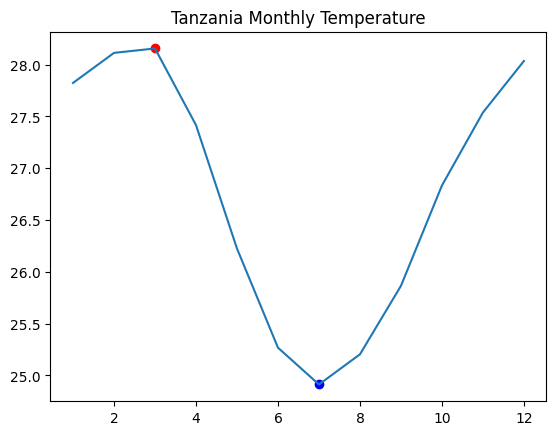

In [9]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.plot(monthly_temp.index, monthly_temp.values)

plt.scatter(warmest, monthly_temp[warmest], color="red")
plt.scatter(coolest, monthly_temp[coolest], color="blue")

plt.title("Tanzania Monthly Temperature")
plt.show()

In [10]:
## Temperature Analysis (Tanzania)

##- Warmest month: (fill from result)
##- Coolest month: (fill from result)

##Clear seasonal variation influenced by tropical climate patterns.

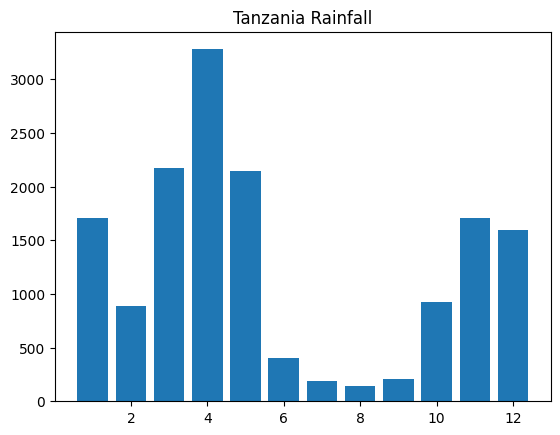

In [11]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Tanzania Rainfall")
plt.show()

In [12]:
## Rainfall Analysis (Tanzania)

##Rainfall is highly seasonal with distinct wet and dry periods.

##- Peak rainfall months: (from chart)
##- Lowest rainfall months: (from chart)

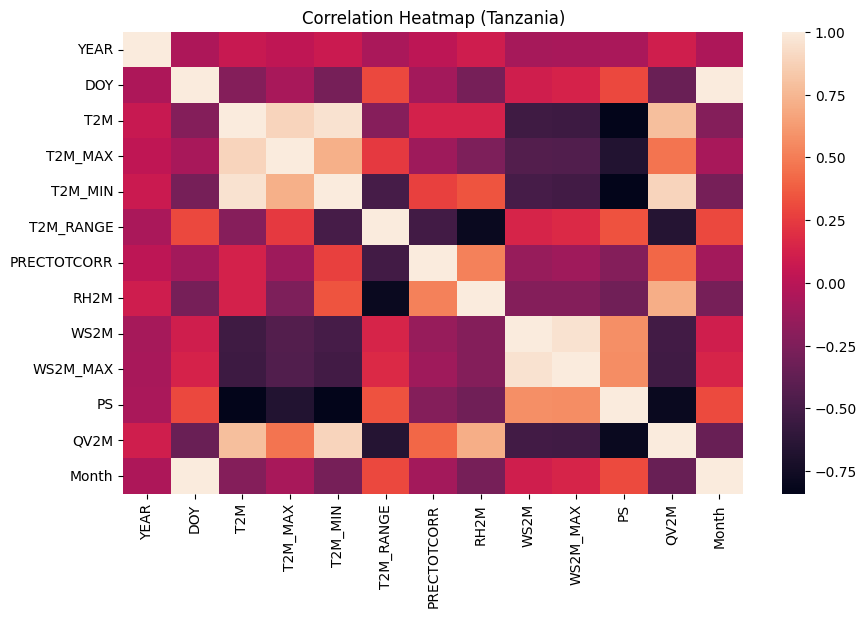

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr)
plt.title("Correlation Heatmap (Tanzania)")
plt.show()

In [14]:
## Correlation Analysis (Tanzania)

##Strong relationships exist between temperature, humidity, and precipitation variables consistent with expected climate dynamics.

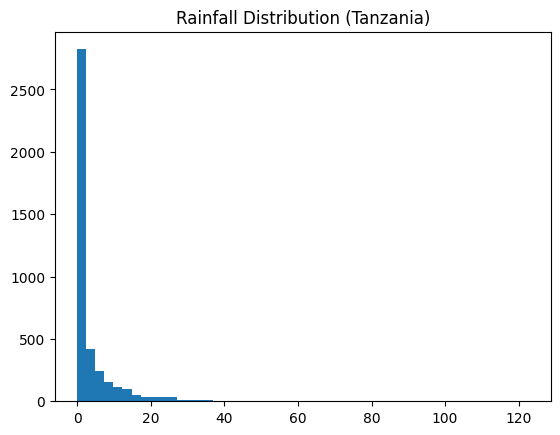

In [15]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution (Tanzania)")
plt.show()

In [16]:
## Rainfall Distribution

##Highly skewed distribution with most days having low rainfall and occasional extreme events.

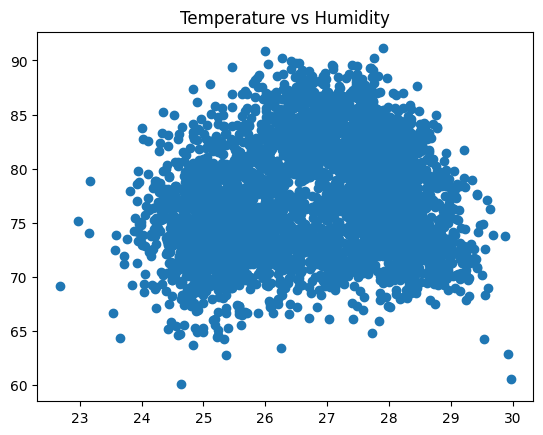

In [17]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.show()

In [18]:
## Temperature vs Humidity

##Inverse relationship observed between temperature and humidity.

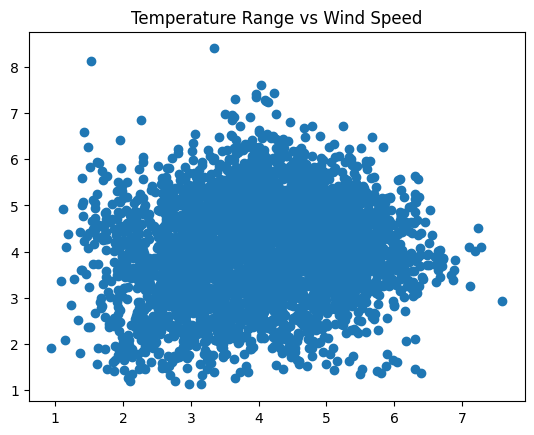

In [19]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.show()

In [20]:
## Wind Speed vs Temperature Range

##Moderate correlation suggests wind influences temperature variability.

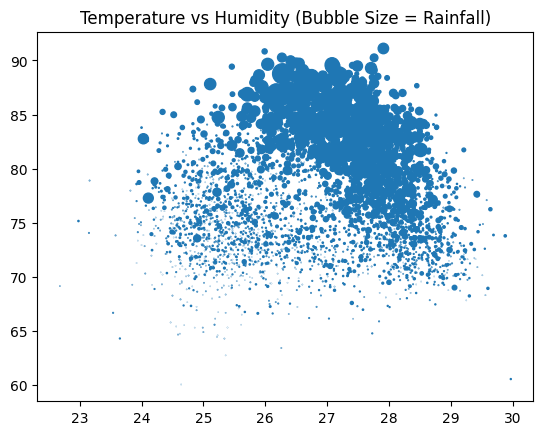

In [21]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2
)

plt.title("Temperature vs Humidity (Bubble Size = Rainfall)")
plt.show()

In [22]:
## Bubble Chart Analysis

##Higher rainfall intensity aligns with higher humidity conditions.

In [23]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(stats.zscore(df[cols]))
outliers = z > 3

outliers.sum(axis=0), outliers.any(axis=1).sum()

(array([ 1,  2,  4, 81,  2,  8,  4]), np.int64(97))

In [24]:
## Outlier Analysis

##Extreme values detected in temperature and rainfall variables. These are retained as they likely represent real climate extremes.

In [25]:
df.to_csv("../data/tanzania_clean.csv", index=False)